<a href="https://colab.research.google.com/github/peemoshi/skillset-ml-internship/blob/main/week-3/3.2-text-classification-project/text_classification_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Financial News Sentiment Classification**

Problem: classify finance-related tweets as Bearish, Bullish or Neutral, so market mood across a large stream of posts can be gauged without reading each one. Data: Twitter Financial News Sentiment (11,931 labelled tweets, MIT license), loaded from Hugging Face. The 65% Neutral majority makes it a realistic test of imbalance handling, so success is judged by macro-F1 and per-class scores, not accuracy alone.

In [1]:
!pip install -q datasets

from datasets import load_dataset

ds = load_dataset("zeroshot/twitter-financial-news-sentiment")
train_df = ds["train"].to_pandas()
valid_df = ds["validation"].to_pandas()

label_names = {0: "Bearish", 1: "Bullish", 2: "Neutral"}

print("Train:", train_df.shape, "| Validation:", valid_df.shape)
print("Columns:", list(train_df.columns))
train_df.head()

README.md:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

sent_train.csv:   0%|          | 0.00/859k [00:00<?, ?B/s]

sent_valid.csv:   0%|          | 0.00/217k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9543 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2388 [00:00<?, ? examples/s]

Train: (9543, 2) | Validation: (2388, 2)
Columns: ['text', 'label']


,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0


Data inspection

Neutral is 64.7% of training tweets (Bullish 20.2%, Bearish 15.1%), so "always Neutral" already scores about 65% accuracy; macro-F1 and per-class results are used instead. There are no missing values or duplicates. Tweets are short (median 11 words, maximum 32), which sets the sequence length later. Labels look partly subjective.

In [2]:
train_df["label_name"] = train_df["label"].map(label_names)

# 1. class balance
counts = train_df["label_name"].value_counts()
print("Class counts:\n", counts, "\n")
print("Class share (%):\n", (counts / len(train_df) * 100).round(1), "\n")

# 2. missing values
print("Missing values:\n", train_df[["text", "label"]].isnull().sum(), "\n")

# 3. duplicates inside train, and overlap between train and validation
print("Duplicate texts in train:", train_df.duplicated(subset="text").sum())
overlap = set(train_df["text"]) & set(valid_df["text"])
print("Texts appearing in both train and validation:", len(overlap), "\n")

# 4. text length in words
print("Words per tweet:\n", train_df["text"].str.split().str.len().describe().round(1), "\n")

# 5. a few random examples per class
for name in ["Bearish", "Bullish", "Neutral"]:
    print(f"--- {name} ---")
    for t in train_df[train_df["label_name"] == name]["text"].sample(3, random_state=1):
        print(" •", t)

Class counts:
 label_name
Neutral    6178
Bullish    1923
Bearish    1442
Name: count, dtype: int64 

Class share (%):
 label_name
Neutral    64.7
Bullish    20.2
Bearish    15.1
Name: count, dtype: float64 

Missing values:
 text     0
label    0
dtype: int64 

Duplicate texts in train: 0
Texts appearing in both train and validation: 0 

Words per tweet:
 count    9543.0
mean       12.2
std         4.7
min         1.0
25%         9.0
50%        11.0
75%        15.0
max        32.0
Name: text, dtype: float64 

--- Bearish ---
 • Why China's coronavirus is more dangerous for the global economy than SARS was in 2003 https://t.co/diuqsVLFOD via @BW
 • The head of loan trading at UBS was terminated after engaging in an allegedly improper transaction https://t.co/3uMpB70a99
 • Walmart Inc.’s Jet subsidiary is ending its fresh-food delivery business just a year after introducing the service… https://t.co/MpzLxKX3cW
--- Bullish ---
 • Analyst: AT&T Is The Top Telecom Pick For 2020
 • Rally go

Cleaning, splits and baseline

Links are removed (they carry no sentiment) and 3 link-only tweets are dropped. Training data is split 85/15 into train and validation, stratified to keep class proportions. The dataset's own validation part becomes the test set, scored once after all choices are made, so the final number is an honest out-of-sample estimate. "Always Neutral" scores 65.6% accuracy but only 0.264 macro-F1, the floor to beat.

In [3]:
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

def clean(text):
    text = re.sub(r"http\S+", "", text)       # remove links
    return re.sub(r"\s+", " ", text).strip()  # tidy spaces

train_df["clean"] = train_df["text"].apply(clean)
test_df = valid_df.copy()
test_df["clean"] = test_df["text"].apply(clean)

# drop tweets that were only a link
print("Empty after cleaning:", (train_df["clean"] == "").sum(), "train |", (test_df["clean"] == "").sum(), "test")
train_df = train_df[train_df["clean"] != ""]
test_df = test_df[test_df["clean"] != ""]

# split train into train / validation (stratified keeps class shares equal)
tr_df, val_df = train_test_split(
    train_df, test_size=0.15, stratify=train_df["label"], random_state=42
)
print("Train:", len(tr_df), "| Val:", len(val_df), "| Test:", len(test_df))

# leakage check after cleaning
print("Cleaned-text overlap train/test:", len(set(tr_df["clean"]) & set(test_df["clean"])))
print("Cleaned-text overlap train/val: ", len(set(tr_df["clean"]) & set(val_df["clean"])))

# baseline: always predict the majority class (Neutral = 2)
pred = [2] * len(test_df)
print("\nMajority baseline on test:")
print("  accuracy :", round(accuracy_score(test_df["label"], pred), 4))
print("  macro-F1 :", round(f1_score(test_df["label"], pred, average="macro"), 4))

Empty after cleaning: 3 train | 0 test
Train: 8109 | Val: 1431 | Test: 2388
Cleaned-text overlap train/test: 29
Cleaned-text overlap train/val:  19

Majority baseline on test:
  accuracy : 0.6558
  macro-F1 : 0.264


Removing leakage

After link removal, 29 training tweets matched test tweets and 19 matched validation tweets. Identical examples on both sides reward memorisation and inflate scores, so duplicates were removed from train and validation only, leaving the test set untouched. Overlap is now zero.

In [4]:
# drop duplicate headlines inside train
tr_df = tr_df.drop_duplicates(subset="clean")

# remove from train/val anything that also appears in the test set,
# and from train anything that also appears in val
val_df = val_df[~val_df["clean"].isin(test_df["clean"])]
tr_df = tr_df[~tr_df["clean"].isin(test_df["clean"])]
tr_df = tr_df[~tr_df["clean"].isin(val_df["clean"])]

print("Train:", len(tr_df), "| Val:", len(val_df), "| Test:", len(test_df))
print("Overlap train/test:", len(set(tr_df["clean"]) & set(test_df["clean"])))
print("Overlap train/val: ", len(set(tr_df["clean"]) & set(val_df["clean"])))
print("Overlap val/test:  ", len(set(val_df["clean"]) & set(test_df["clean"])))
print("\nTrain class share (%):")
print((tr_df["label"].map(label_names).value_counts(normalize=True) * 100).round(1))

Train: 7981 | Val: 1420 | Test: 2388
Overlap train/test: 0
Overlap train/val:  0
Overlap val/test:   0

Train class share (%):
label
Neutral    64.6
Bullish    20.3
Bearish    15.1
Name: proportion, dtype: float64


Stronger baseline: TF-IDF + logistic regression

A complex model should be compared with a strong simple one. This baseline uses word and word-pair counts, with class weights so rare classes are not ignored, and is fitted on training data only. Validation: 80.7% accuracy, 0.742 macro-F1, the bar the Keras model must clear.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
X_tr = vec.fit_transform(tr_df["clean"])
X_val = vec.transform(val_df["clean"])

clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_tr, tr_df["label"])

pred_val = clf.predict(X_val)
print(classification_report(
    val_df["label"], pred_val,
    target_names=["Bearish", "Bullish", "Neutral"], digits=3
))

              precision    recall  f1-score   support

     Bearish      0.622     0.642     0.632       215
     Bullish      0.716     0.716     0.716       289
     Neutral      0.881     0.874     0.878       916

    accuracy                          0.807      1420
   macro avg      0.740     0.744     0.742      1420
weighted avg      0.808     0.807     0.808      1420



Keras model v1

Text vectorisation sits inside the model (vocabulary learned from train only), so the saved model accepts raw text. The network is a 64-dimensional embedding, a bidirectional LSTM and dropout (665,027 parameters). Sequence length is 32, the longest tweet, so no text is cut.

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)

X_tr  = tf.constant(tr_df["clean"].tolist());   y_tr  = tr_df["label"].values
X_val = tf.constant(val_df["clean"].tolist());  y_val = val_df["label"].values
X_te  = tf.constant(test_df["clean"].tolist()); y_te  = test_df["label"].values

MAX_TOKENS = 10000
MAX_LEN = 32

vectorizer = layers.TextVectorization(max_tokens=MAX_TOKENS, output_sequence_length=MAX_LEN)
vectorizer.adapt(tr_df["clean"].tolist())   # vocabulary learned from TRAIN only

vocab = vectorizer.get_vocabulary()
print("Vocabulary size:", len(vocab))
print("Most common:", vocab[:10])
print("Example:", vectorizer(tf.constant(["Rally goes on as China cuts U.S. tariffs"])).numpy()[0])

Vocabulary size: 10000
Most common: ['', '[UNK]', np.str_('to'), np.str_('the'), np.str_('of'), np.str_('in'), np.str_('on'), np.str_('a'), np.str_('for'), np.str_('and')]
Example: [217 333   6  13  49 166  18 500   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


In [7]:
model = keras.Sequential([
    keras.Input(shape=(), dtype="string"),
    vectorizer,
    layers.Embedding(MAX_TOKENS, 64, mask_zero=True),
    layers.Bidirectional(layers.LSTM(32)),
    layers.Dropout(0.5),
    layers.Dense(3),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 32)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 32, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 665,027 (2.54 MB)

 Trainable params: 665,027 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

Class weights

Mistakes on rare classes are weighted more heavily (Bearish counts about four times Neutral), so the model cannot score well by over-predicting Neutral. In market settings, missing a bearish or bullish signal can cost more than mislabelling a neutral headline, so unequal error costs are a sensible default. The weights here are balanced, not tuned to a specific cost.

In [8]:
from sklearn.utils.class_weight import compute_class_weight

cw = compute_class_weight("balanced", classes=np.array([0, 1, 2]), y=y_tr)
class_weight = dict(enumerate(cw))
print("Class weights:", {k: round(v, 2) for k, v in class_weight.items()})

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

Class weights: {0: np.float64(2.21), 1: np.float64(1.64), 2: np.float64(0.52)}


Training and overfitting

Early stopping on validation loss (patience 3, best weights restored) ends training when validation stops improving, instead of guessing an epoch count. The best epoch was the first (validation accuracy 76.6%, validation loss 0.639); after that, validation loss rose while training accuracy climbed to 96%, a sign of memorisation. On validation, v1 scored 76.5% accuracy and 0.690 macro-F1, below the simple baseline, so the extra complexity was not justified by the amount of data.

In [9]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[early_stop],
)

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.6542 - loss: 0.8947 - val_accuracy: 0.7655 - val_loss: 0.6392
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.8542 - loss: 0.4410 - val_accuracy: 0.7542 - val_loss: 0.6455
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.9291 - loss: 0.2229 - val_accuracy: 0.7563 - val_loss: 0.7343
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.9595 - loss: 0.1209 - val_accuracy: 0.7549 - val_loss: 0.8443


In [10]:
from sklearn.metrics import classification_report

model_v1 = model
pred_v1 = model_v1.predict(X_val, verbose=0).argmax(axis=1)
print(classification_report(
    y_val, pred_v1, target_names=["Bearish", "Bullish", "Neutral"], digits=3
))

              precision    recall  f1-score   support

     Bearish      0.523     0.577     0.549       215
     Bullish      0.657     0.682     0.669       289
     Neutral      0.867     0.836     0.852       916

    accuracy                          0.765      1420
   macro avg      0.682     0.698     0.690      1420
weighted avg      0.772     0.765     0.769      1420



Model v2

To cut overfitting, v2 averages embeddings instead of using an LSTM, with smaller embeddings, more dropout and a lower learning rate (about 320,000 parameters). Training returned nan loss and the model predicted one class for everything.

In [11]:
tf.keras.utils.set_random_seed(42)

model_v2 = keras.Sequential([
    keras.Input(shape=(), dtype="string"),
    vectorizer,
    layers.Embedding(MAX_TOKENS, 32, mask_zero=True),
    layers.SpatialDropout1D(0.3),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.3),
    layers.Dense(16, activation="relu"),
    layers.Dense(3),
])

model_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)
history_v2 = model_v2.fit(
    X_tr, y_tr, validation_data=(X_val, y_val),
    epochs=30, batch_size=32, class_weight=class_weight,
    callbacks=[early_stop], verbose=2,
)

pred_v2 = model_v2.predict(X_val, verbose=0).argmax(axis=1)
print(classification_report(
    y_val, pred_v2, target_names=["Bearish", "Bullish", "Neutral"], digits=3
))

Epoch 1/30
250/250 - 10s - 41ms/step - accuracy: 0.2393 - loss: nan - val_accuracy: 0.1514 - val_loss: nan
Epoch 2/30
250/250 - 5s - 22ms/step - accuracy: 0.1510 - loss: nan - val_accuracy: 0.1514 - val_loss: nan
Epoch 3/30
250/250 - 2s - 6ms/step - accuracy: 0.1510 - loss: nan - val_accuracy: 0.1514 - val_loss: nan
Epoch 4/30
250/250 - 2s - 9ms/step - accuracy: 0.1510 - loss: nan - val_accuracy: 0.1514 - val_loss: nan
              precision    recall  f1-score   support

     Bearish      0.151     1.000     0.263       215
     Bullish      0.000     0.000     0.000       289
     Neutral      0.000     0.000     0.000       916

    accuracy                          0.151      1420
   macro avg      0.050     0.333     0.088      1420
weighted avg      0.023     0.151     0.040      1420



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Diagnosis and fix

One training tweet had no usable words after standardisation. With padding masked, the averaging layer most likely divided by zero and the nan spread to every weight. Removing the mask fixed it. v2 reached 79.2% validation accuracy and 0.716 macro-F1 and was chosen as the Keras model on validation results, not test.

In [12]:
print("Keras version:", keras.__version__)

for name, X in [("train", X_tr), ("val", X_val), ("test", X_te)]:
    empty = (vectorizer(X).numpy().sum(axis=1) == 0).sum()
    print(f"{name}: {empty} tweets with no usable words")

tf.keras.utils.set_random_seed(42)

model_v2 = keras.Sequential([
    keras.Input(shape=(), dtype="string"),
    vectorizer,
    layers.Embedding(MAX_TOKENS, 32),
    layers.SpatialDropout1D(0.3),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.3),
    layers.Dense(16, activation="relu"),
    layers.Dense(3),
])

model_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)
history_v2 = model_v2.fit(
    X_tr, y_tr, validation_data=(X_val, y_val),
    epochs=30, batch_size=32, class_weight=class_weight,
    callbacks=[early_stop], verbose=2,
)

pred_v2 = model_v2.predict(X_val, verbose=0).argmax(axis=1)
print(classification_report(
    y_val, pred_v2, target_names=["Bearish", "Bullish", "Neutral"],
    digits=3, zero_division=0
))

Keras version: 3.13.2
train: 1 tweets with no usable words
val: 0 tweets with no usable words
test: 0 tweets with no usable words
Epoch 1/30
250/250 - 7s - 28ms/step - accuracy: 0.2724 - loss: 1.0965 - val_accuracy: 0.2782 - val_loss: 1.1053
Epoch 2/30
250/250 - 2s - 7ms/step - accuracy: 0.4058 - loss: 1.0857 - val_accuracy: 0.4803 - val_loss: 1.0830
Epoch 3/30
250/250 - 2s - 7ms/step - accuracy: 0.5418 - loss: 1.0501 - val_accuracy: 0.6923 - val_loss: 0.9905
Epoch 4/30
250/250 - 2s - 6ms/step - accuracy: 0.6623 - loss: 0.9657 - val_accuracy: 0.7000 - val_loss: 0.8906
Epoch 5/30
250/250 - 2s - 6ms/step - accuracy: 0.7389 - loss: 0.8436 - val_accuracy: 0.7331 - val_loss: 0.7791
Epoch 6/30
250/250 - 2s - 6ms/step - accuracy: 0.7882 - loss: 0.7163 - val_accuracy: 0.7493 - val_loss: 0.6919
Epoch 7/30
250/250 - 3s - 10ms/step - accuracy: 0.8237 - loss: 0.6108 - val_accuracy: 0.7704 - val_loss: 0.6392
Epoch 8/30
250/250 - 4s - 16ms/step - accuracy: 0.8459 - loss: 0.5165 - val_accuracy: 0.778

Test results (scored once)

All models beat the majority baseline decisively. TF-IDF (79.9%, 0.738 macro-F1) and Keras v2 (79.1%, 0.715) are close, with TF-IDF better on Bearish and Bullish. With one run per model, a gap this small is not conclusive. Test scores match validation, so model selection did not overfit to the validation set.

In [13]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

preds = {
    "Always Neutral (majority)": np.full(len(y_te), 2),
    "TF-IDF + Logistic Regression": clf.predict(vec.transform(test_df["clean"])),
    "Keras v1 (BiLSTM)": model_v1.predict(X_te, verbose=0).argmax(axis=1),
    "Keras v2 (averaged embeddings)": model_v2.predict(X_te, verbose=0).argmax(axis=1),
}

rows = []
for name, p in preds.items():
    per_class = f1_score(y_te, p, average=None, labels=[0, 1, 2], zero_division=0)
    rows.append([
        name,
        accuracy_score(y_te, p),
        f1_score(y_te, p, average="macro", zero_division=0),
        *per_class,
    ])

results = pd.DataFrame(
    rows,
    columns=["Model", "Accuracy", "Macro-F1", "F1 Bearish", "F1 Bullish", "F1 Neutral"],
).round(3)
results

,Model,Accuracy,Macro-F1,F1 Bearish,F1 Bullish,F1 Neutral
0,Always Neutral (majority),0.656,0.264,0.000,0.000,0.792
1,TF-IDF + Logistic Regression,0.799,0.738,0.637,0.708,0.869
2,Keras v1 (BiLSTM),0.761,0.687,0.555,0.657,0.850
3,Keras v2 (averaged embeddings),0.791,0.715,0.603,0.667,0.873


Error analysis

v2 made 499 mistakes in 2,388 tweets. Neutral is involved in 79% of them (395), while confusing Bullish with Bearish is only 21%, so the hard part is deciding whether a tweet carries sentiment at all. Examples show negative-sounding words in tweets that take no stance ("bankruptcy", "resistance"), mixed signals ("beats on EPS, misses on revenue") and probable label errors ("it's going to get worse" labelled Neutral). The examples are a small qualitative sample.

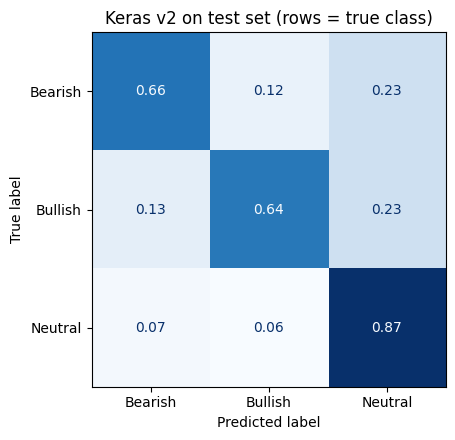

Total mistakes: 499 of 2388


,clean,true,predicted,confidence
2056,$SCANX: Stocks/ETFs that traded to new 52 week highs/lows this session - New highs (37) outpacing new lows...,Neutral,Bullish,0.99
111,Jerome Powell comes close to acknowledging that the Federal Reserve may not have the firepower to fight th...,Bearish,Neutral,0.99
801,Bipartisan Group Of US Lawmakers Introduce Bill Providing $3B To Buy Oil To Fill Strategic Petroleum Reser...,Bullish,Neutral,0.99
961,"Highlight: ""We're gonna see companies start to report results and I think it's gonna look ugly,"" @FBBCap's...",Bearish,Neutral,0.99
813,$UNG $DGAZ $UGAZ - Natural gas inventory draw in-line with estimates,Neutral,Bullish,0.98
905,The Estée Lauder Companies Delivers Exceptional Fiscal 2020 Second Quarter Results,Bullish,Neutral,0.98
1466,Fiat reaches settlement with Italy tax agency over Chrysler value claim,Bullish,Neutral,0.98
1599,"Austria is planning the first steps to restart its economy as soon as next week, the first European countr...",Bullish,Neutral,0.98
2019,"Why Ebix, Inc. (NASDAQ:EBIX) Should Be In Your Dividend Portfolio",Bullish,Neutral,0.98
105,Wayfair initiated as hold with $95 price target at SunTrust Robinson Humphrey,Neutral,Bullish,0.98


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

names = ["Bearish", "Bullish", "Neutral"]
probs = tf.nn.softmax(model_v2.predict(X_te, verbose=0)).numpy()
pred_te = probs.argmax(axis=1)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_te, pred_te, display_labels=names, normalize="true",
    cmap="Blues", values_format=".2f", ax=ax, colorbar=False,
)
ax.set_title("Keras v2 on test set (rows = true class)")
plt.tight_layout()
plt.show()

errors = test_df.copy()
errors["true"] = [names[i] for i in y_te]
errors["predicted"] = [names[i] for i in pred_te]
errors["confidence"] = probs.max(axis=1).round(2)
errors = errors[errors["true"] != errors["predicted"]]

print("Total mistakes:", len(errors), "of", len(test_df))
pd.set_option("display.max_colwidth", 110)
errors.sort_values("confidence", ascending=False)[["clean", "true", "predicted", "confidence"]].head(12)

In [15]:
print(pd.crosstab(errors["true"], errors["predicted"]), "\n")

share = (errors.groupby(["true", "predicted"]).size() / len(errors) * 100).round(1)
print("Share of all mistakes (%):")
print(share.sort_values(ascending=False))

predicted  Bearish  Bullish  Neutral
true                                
Bearish          0       40       79
Bullish         64        0      107
Neutral        117       92        0 

Share of all mistakes (%):
true     predicted
Neutral  Bearish      23.4
Bullish  Neutral      21.4
Neutral  Bullish      18.4
Bearish  Neutral      15.8
Bullish  Bearish      12.8
Bearish  Bullish       8.0
dtype: float64


In [17]:
grp = errors[(errors["true"] == "Neutral") & (errors["predicted"] == "Bearish")]
for t in grp["clean"].sample(8, random_state=1):
    print("•", t)

• Highlight: @julialaroche breaks down Jamie Dimon's letter to $JPM shareholders:
• CAE EPS beats by C$0.02, misses on revenue
• Billionaire investor Howard Marks says we're not in a bubble, but sees reasons to take less risk
• Macy's has shrunk to the size of Beyond Meat. It's going to get worse, technician says $M $BYND (via @TradingNation)
• On this day in 1994 Orange County, California filed for bankruptcy protection after interest rate swaps imploded in…
• Q4 GDP: Trudging Along. #business #stockmarket #stocks
• Flurry of retailer earnings on tap
• EUR/USD Price Forecast – Euro Continues To Grind Towards Resistance


In [16]:
model_v2.save("financial_sentiment_keras.keras")
reloaded = keras.models.load_model("financial_sentiment_keras.keras")

# check the reloaded file gives the same test accuracy
re_pred = reloaded.predict(X_te, verbose=0).argmax(axis=1)
print("Reloaded model test accuracy:", round(accuracy_score(y_te, re_pred), 4))

def predict_sentiment(texts):
    """Take one tweet or a list of tweets, return label + confidence for each."""
    if isinstance(texts, str):
        texts = [texts]
    cleaned = [clean(t) for t in texts]
    probs = tf.nn.softmax(reloaded.predict(tf.constant(cleaned), verbose=0)).numpy()
    out = []
    for original, text, p in zip(texts, cleaned, probs):
        if not text:
            out.append({"text": original, "label": "No text to classify", "confidence": None})
        else:
            out.append({"text": original, "label": names[p.argmax()],
                        "confidence": round(float(p.max()), 2)})
    return out

samples = [
    "Fed signals more rate cuts as markets rally to record highs",
    "Shares plunge after company slashes full-year earnings guidance",
    "Quarterly earnings call scheduled for Thursday at 5pm ET",
    "https://t.co/abc123",
]
for r in predict_sentiment(samples):
    print(r)

Reloaded model test accuracy: 0.791
{'text': 'Fed signals more rate cuts as markets rally to record highs', 'label': 'Bullish', 'confidence': 0.86}
{'text': 'Shares plunge after company slashes full-year earnings guidance', 'label': 'Bearish', 'confidence': 0.94}
{'text': 'Quarterly earnings call scheduled for Thursday at 5pm ET', 'label': 'Neutral', 'confidence': 0.75}
{'text': 'https://t.co/abc123', 'label': 'No text to classify', 'confidence': None}


**Summary, limitations and next steps**

The Keras model reaches 79.1% test accuracy and 0.715 macro-F1 against a 65.6% majority baseline, but does not beat the simple TF-IDF baseline (79.9%, 0.738). At this data size, simpler was as good.

Limitations: labels are subjective and partly noisy, which caps accuracy. Each model was run once, so small gaps are unreliable. The training set is about 8,000 tweets. The split is random, not chronological, so results say little about performance on future data, and the tweets appear to date from around 2020. Confidence scores are not calibrated.

Next steps: a time-based split to test out-of-time performance, multiple seeds to measure variance, pretrained embeddings or a small transformer, label review, and checking whether the predicted sentiment adds anything to a real decision, for example in a backtest.